# MediCore Health Network — Dataset Cleaning

This notebook cleans `medicore_raw.csv` in the following order:

1. Remove duplicate rows, reset index
2. Replace whitespace-only/empty strings with NaN
3. Fix `Patient_Age` (abs negatives, remove age > 100)
4. Fix `Length_Of_Stay` (abs negatives, IQR outlier removal)
5. `Billing_Amount` IQR outlier removal
6. Fill remaining nulls (median / mean / random-choice / group median)
7. Standardize text values (strip, lower, title, underscore)
8. Standardize column names (Title_Case_With_Underscores)
9. Fix `Admission_Date` mixed formats
10. Finalize data types
11. Print cleaning summary report

In [4]:
import pandas as pd
import numpy as np
from IPython.display import Image, display

In [5]:
# Load raw dataset

In [6]:
df = pd.read_csv("medicore_raw.csv")
starting_rows = len(df)
print('Starting shape:', df.shape)
df.head()

Starting shape: (13453, 14)


,patient_id,visit_id,admission_date,department,region,city,patient_age,gender,length_of_stay,billing_amount,insurance_type,is_emergency,readmission,satisfaction_score
0,PAT101530,VIS106050,2024-10-24,orthopedics,West,Mumbai,80.0,Male,90.0,51208.29,Government Scheme,Scheduled,No,4.0
1,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19.0,Female,3.0,73041.40,Self-Pay,Scheduled,No,4.0
2,PAT101791,VIS107125,2024-10-06,GENERAL MEDICINE,West,pune,24.0,Male,2.0,16271.49,Private Insurance,Scheduled,No,5.0
3,PAT100933,VIS103727,23/05/2024,Oncology,East,Kolkata,52.0,Male,NaN,74144.16,Corporate Insurance,Scheduled,No,NaN
4,PAT101832,VIS107290,2025-11-09,orthopedics,South,Kochi,39.0,Male,8.0,47344.12,Self-Pay,Scheduled,No,3.0


In [7]:
removal_log = {} 

In [8]:
# Remove duplicate rows, reset index

In [9]:
before = len(df)
df = df.drop_duplicates()
df = df.reset_index(drop=True)
after = len(df)
removal_log['Duplicate Rows'] = before - after
print(f'Removed {before-after} duplicate rows. Remaining: {after}')

Removed 1441 duplicate rows. Remaining: 12012


In [10]:
# Replace whitespace-only and empty strings with NaN

In [11]:
df = df.replace(r'^\s*$', np.nan, regex=True)
print('Whitespace-only cells converted to NaN.')
df.isnull().sum()

Whitespace-only cells converted to NaN.


patient_id              0
visit_id                0
admission_date          0
department              0
region                  0
city                    0
patient_age           240
gender                  0
length_of_stay        360
billing_amount        480
insurance_type        300
is_emergency            0
readmission             0
satisfaction_score    720
dtype: int64

In [12]:
#Convert negative ages to positive andremove rows where age > 100.

In [13]:
df['patient_age'] = df['patient_age'].abs()

before = len(df)
df = df[(df['patient_age'] <= 100) | (df['patient_age'].isnull())]   #NaN <= 100 is always False so we are also keping the null values in the df
after = len(df)
removal_log['Patient_Age (> 100)'] = before - after
print(f'Removed {before-after} rows where age > 100. Remaining: {after}')

Removed 85 rows where age > 100. Remaining: 11927


In [14]:
#Convert negative stays to positive  and remove IQR outliers.

In [15]:
df['length_of_stay'] = df['length_of_stay'].abs()

Q1 = df['length_of_stay'].quantile(0.25)
Q3 = df['length_of_stay'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df)                      
outlier_mask = (df['length_of_stay'] < lower) | (df['length_of_stay'] > upper)
df = df[~outlier_mask]          # here the false values becomes true beacuse those are not outliers the above ones are outliers which are ture
after = len(df)
removal_log['Length_Of_Stay (IQR outliers)'] = before - after
print(f'IQR bounds: [{lower:.2f}, {upper:.2f}]')
print(f'Removed {before-after} outlier rows. Remaining: {after}')

IQR bounds: [-2.50, 9.50]
Removed 884 outlier rows. Remaining: 11043


In [16]:
# outliers removal

In [17]:
Q1 = df['billing_amount'].quantile(0.25)
Q3 = df['billing_amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df)
outlier_mask = (df['billing_amount'] < lower) | (df['billing_amount'] > upper)
df = df[~outlier_mask]
after = len(df)
removal_log['Billing_Amount (IQR outliers)'] = before - after
print(f'IQR bounds: [{lower:.2f}, {upper:.2f}]')
print(f'Removed {before-after} outlier rows. Remaining: {after}')

IQR bounds: [-34796.97, 98806.17]
Removed 164 outlier rows. Remaining: 10879


In [18]:
df = df.reset_index(drop=True)
print('Shape after all outlier/invalid-value handling:', df.shape)

Shape after all outlier/invalid-value handling: (10879, 14)


In [19]:
#Fill remaining null values

In [20]:
median_los = df['length_of_stay'].median()
df['length_of_stay'] = df['length_of_stay'].fillna(median_los)
print('Filled length_of_stay nulls with median:', median_los)

Filled length_of_stay nulls with median: 3.0


In [21]:
mean_age = df['patient_age'].mean()
df['patient_age'] = df['patient_age'].fillna(mean_age)
print('Filled patient_age nulls with mean:', round(mean_age, 2))

Filled patient_age nulls with mean: 44.2


In [22]:
# distribution-preserving random fill

In [23]:
probs = df['insurance_type'].value_counts(normalize=True)
missing = df['insurance_type'].isnull()
df.loc[missing, 'insurance_type'] = np.random.choice(probs.index, missing.sum(), p=probs.values)
print(f'Filled {missing.sum()} insurance_type nulls using distribution-preserving random choice.')

Filled 263 insurance_type nulls using distribution-preserving random choice.


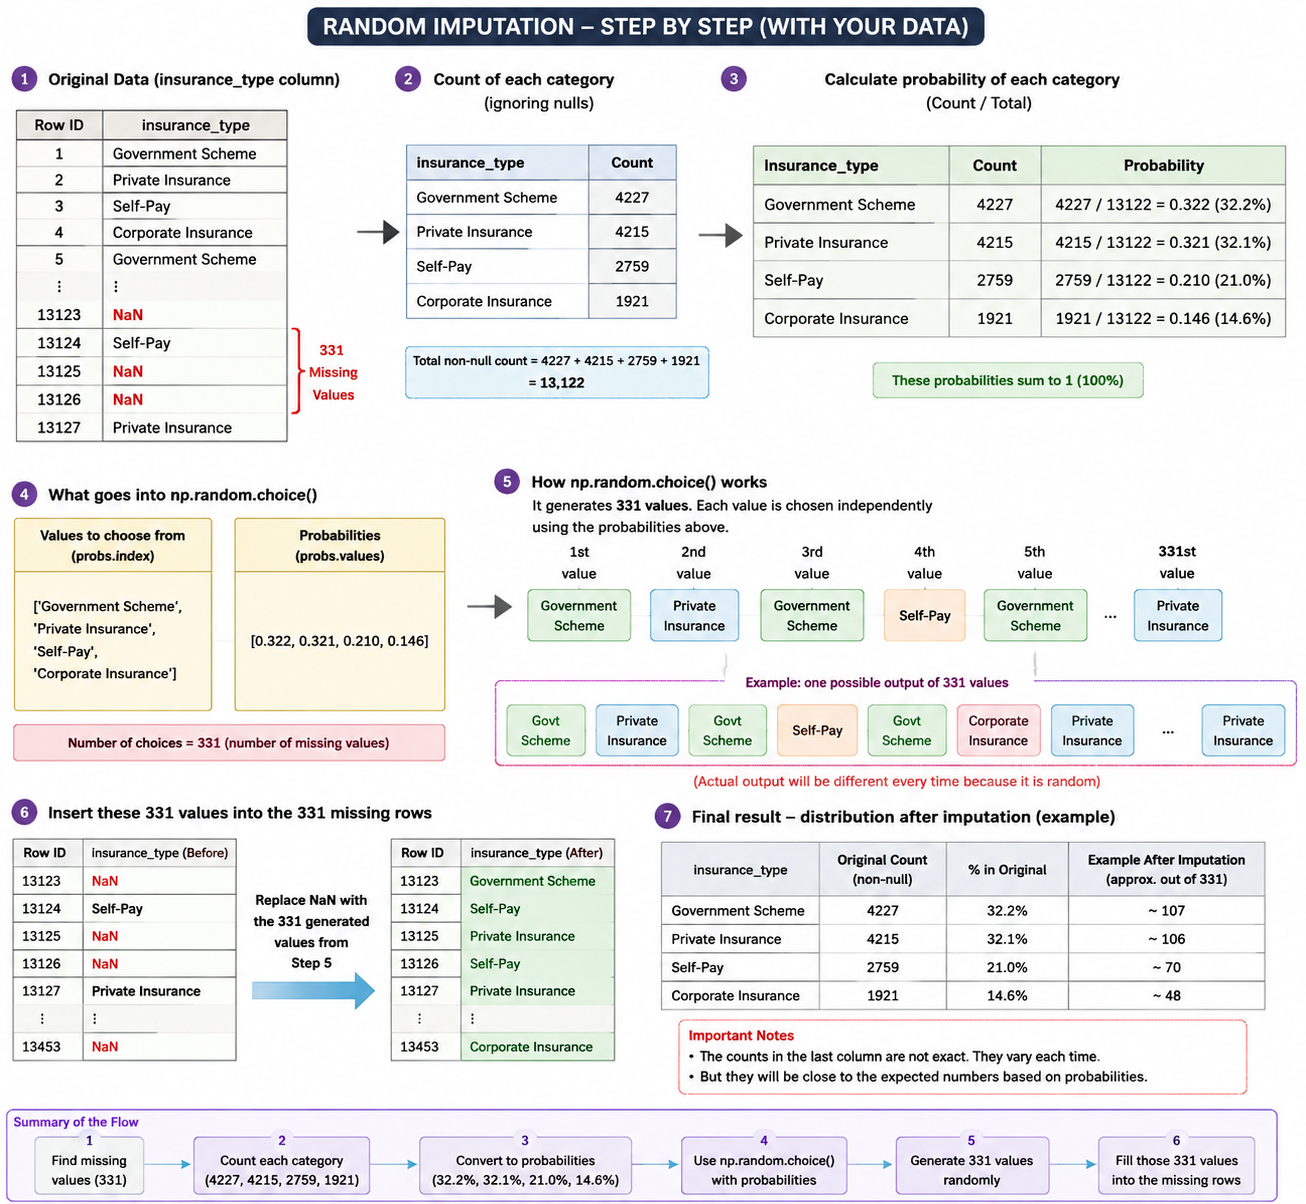

In [24]:
display(Image(filename=r"C:\Users\surya_t4rpfms\Downloads\ChatGPT Image Aug 5, 2026, 11_06_51 AM.png", width=700, height=500))

In [25]:
probs = df['satisfaction_score'].value_counts(normalize=True)
missing = df['satisfaction_score'].isnull()
df.loc[missing, 'satisfaction_score'] = np.random.choice(probs.index, missing.sum(), p=probs.values)
print(f'Filled {missing.sum()} satisfaction_score nulls using distribution-preserving random choice.')

# display(Image(filename=r"C:\Users\surya_t4rpfms\Downloads\ChatGPT Image Aug 5, 2026, 11_26_48 AM.png", width=700, height=500))

Filled 655 satisfaction_score nulls using distribution-preserving random choice.


In [26]:
df.head()

,patient_id,visit_id,admission_date,department,region,city,patient_age,gender,length_of_stay,billing_amount,insurance_type,is_emergency,readmission,satisfaction_score
0,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19.0,Female,3.0,73041.40,Self-Pay,Scheduled,No,4.0
1,PAT101791,VIS107125,2024-10-06,GENERAL MEDICINE,West,pune,24.0,Male,2.0,16271.49,Private Insurance,Scheduled,No,5.0
2,PAT100933,VIS103727,23/05/2024,Oncology,East,Kolkata,52.0,Male,3.0,74144.16,Corporate Insurance,Scheduled,No,5.0
3,PAT101832,VIS107290,2025-11-09,orthopedics,South,Kochi,39.0,Male,8.0,47344.12,Self-Pay,Scheduled,No,3.0
4,PAT102084,VIS108341,2025-02-06,ONCOLOGY,West,pune,56.0,Male,7.0,69814.70,Corporate Insurance,Emergency,No,5.0


In [27]:
#billing_amount → group-wise median (department, length_of_stay, insurance_type, is_emergency)

In [28]:
df['billing_amount'] = df['billing_amount'].fillna(
    df.groupby(['department', 'length_of_stay', 'insurance_type', 'is_emergency'])['billing_amount'].transform('median')
)

# fallback for any groups that had zero real values (median = NaN) -> overall median
remaining_null = df['billing_amount'].isnull().sum()
if remaining_null > 0:
    overall_median = df['billing_amount'].median()
    df['billing_amount'] = df['billing_amount'].fillna(overall_median)
    print(f'Fallback: filled {remaining_null} remaining billing_amount nulls with overall median ({overall_median:.2f}).')

print('Remaining nulls in billing_amount:', df['billing_amount'].isnull().sum())

Fallback: filled 2 remaining billing_amount nulls with overall median (22211.07).
Remaining nulls in billing_amount: 0


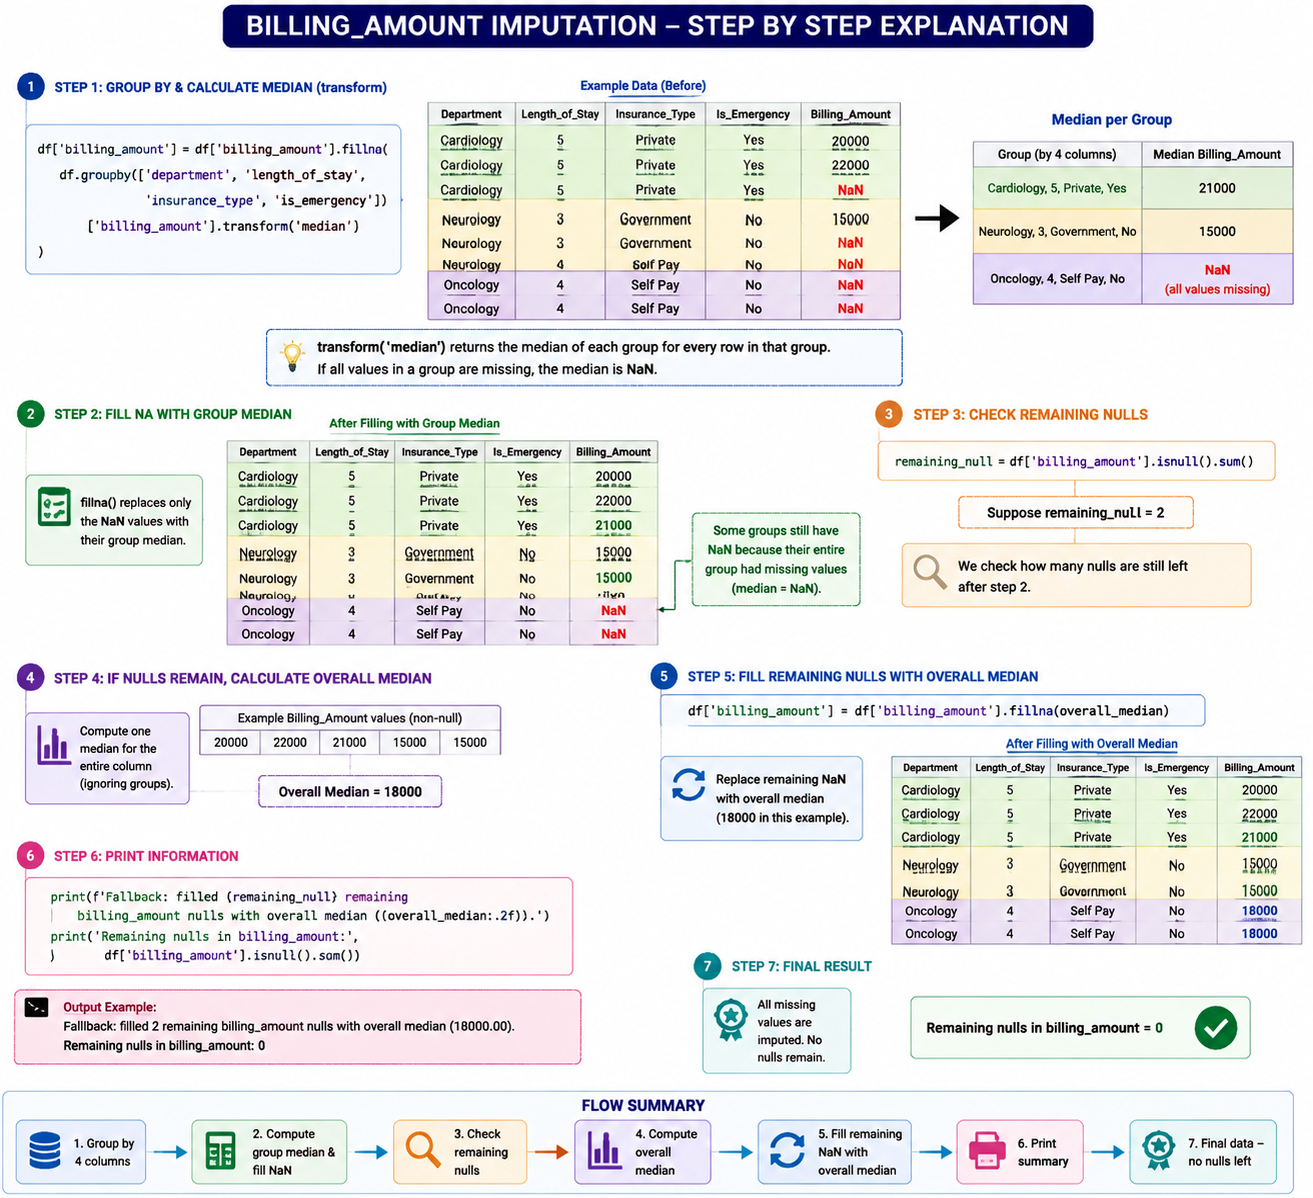

In [29]:
display(Image(filename=r"C:\Users\surya_t4rpfms\Downloads\ChatGPT Image Aug 5, 2026, 11_36_24 AM.png", width=700, height=500))

In [30]:
print('Nulls remaining across dataset:')
df.isnull().sum()

Nulls remaining across dataset:


patient_id            0
visit_id              0
admission_date        0
department            0
region                0
city                  0
patient_age           0
gender                0
length_of_stay        0
billing_amount        0
insurance_type        0
is_emergency          0
readmission           0
satisfaction_score    0
dtype: int64

In [31]:
text_cols = df.select_dtypes(include='object').columns.tolist()
for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.title()
        .str.replace(' ', '_', regex=False)
    )

C:\Users\surya_t4rpfms\AppData\Local\Temp\ipykernel_16488\2441124710.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns.tolist()


In [32]:
df.head()

,patient_id,visit_id,admission_date,department,region,city,patient_age,gender,length_of_stay,billing_amount,insurance_type,is_emergency,readmission,satisfaction_score
0,Pat102385,Vis109552,2024-07-17,Oncology,East,Guwahati,19.0,Female,3.0,73041.40,Self-Pay,Scheduled,No,4.0
1,Pat101791,Vis107125,2024-10-06,General_Medicine,West,Pune,24.0,Male,2.0,16271.49,Private_Insurance,Scheduled,No,5.0
2,Pat100933,Vis103727,23/05/2024,Oncology,East,Kolkata,52.0,Male,3.0,74144.16,Corporate_Insurance,Scheduled,No,5.0
3,Pat101832,Vis107290,2025-11-09,Orthopedics,South,Kochi,39.0,Male,8.0,47344.12,Self-Pay,Scheduled,No,3.0
4,Pat102084,Vis108341,2025-02-06,Oncology,West,Pune,56.0,Male,7.0,69814.70,Corporate_Insurance,Emergency,No,5.0


In [33]:
change = ["patient_id", "visit_id"]

for col in change:
    df[col] = df[col].astype(str).str.upper()

In [34]:
df.head()

,patient_id,visit_id,admission_date,department,region,city,patient_age,gender,length_of_stay,billing_amount,insurance_type,is_emergency,readmission,satisfaction_score
0,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19.0,Female,3.0,73041.40,Self-Pay,Scheduled,No,4.0
1,PAT101791,VIS107125,2024-10-06,General_Medicine,West,Pune,24.0,Male,2.0,16271.49,Private_Insurance,Scheduled,No,5.0
2,PAT100933,VIS103727,23/05/2024,Oncology,East,Kolkata,52.0,Male,3.0,74144.16,Corporate_Insurance,Scheduled,No,5.0
3,PAT101832,VIS107290,2025-11-09,Orthopedics,South,Kochi,39.0,Male,8.0,47344.12,Self-Pay,Scheduled,No,3.0
4,PAT102084,VIS108341,2025-02-06,Oncology,West,Pune,56.0,Male,7.0,69814.70,Corporate_Insurance,Emergency,No,5.0


In [38]:
df['Admission_Date'] = pd.to_datetime(df['admission_date'], format='mixed')
df['Patient_Age'] = df['patient_age'].round().astype(int)
df['Length_Of_Stay'] = df['length_of_stay'].round().astype(int)
df['Satisfaction_Score'] = df['satisfaction_score'].round().astype(int)
df['Billing_Amount'] = df['billing_amount'].round(2)

In [39]:
df.dtypes

patient_id                       str
visit_id                         str
admission_date                   str
department                       str
region                           str
city                             str
patient_age                  float64
gender                           str
length_of_stay               float64
billing_amount               float64
insurance_type                   str
is_emergency                     str
readmission                      str
satisfaction_score           float64
Admission_Date        datetime64[us]
Patient_Age                    int64
Length_Of_Stay                 int64
Satisfaction_Score             int64
Billing_Amount               float64
dtype: object

In [40]:
# rows removal data

In [41]:
ending_rows = len(df)
total_removed = starting_rows - ending_rows

print('='*55)
print('DATA CLEANING SUMMARY')
print('='*55)
print(f'Starting row count : {starting_rows}')
print(f'Ending row count   : {ending_rows}')
print(f'Total rows removed : {total_removed}')
print('-'*55)
print('Rows removed by column / step:')
for step, count in removal_log.items():
    print(f'  - {step}: {count} rows removed')
print('='*55)

DATA CLEANING SUMMARY
Starting row count : 13453
Ending row count   : 10879
Total rows removed : 2574
-------------------------------------------------------
Rows removed by column / step:
  - Duplicate Rows: 1441 rows removed
  - Patient_Age (> 100): 85 rows removed
  - Length_Of_Stay (IQR outliers): 884 rows removed
  - Billing_Amount (IQR outliers): 164 rows removed


In [42]:
df.to_csv('medicore_cleaned2.csv', index=False)
print('Saved medicore_cleaned.csv')
df.head()

Saved medicore_cleaned.csv


,patient_id,visit_id,admission_date,department,region,city,patient_age,gender,length_of_stay,billing_amount,insurance_type,is_emergency,readmission,satisfaction_score,Admission_Date,Patient_Age,Length_Of_Stay,Satisfaction_Score,Billing_Amount
0,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19.0,Female,3.0,73041.40,Self-Pay,Scheduled,No,4.0,2024-07-17,19,3,4,73041.40
1,PAT101791,VIS107125,2024-10-06,General_Medicine,West,Pune,24.0,Male,2.0,16271.49,Private_Insurance,Scheduled,No,5.0,2024-10-06,24,2,5,16271.49
2,PAT100933,VIS103727,23/05/2024,Oncology,East,Kolkata,52.0,Male,3.0,74144.16,Corporate_Insurance,Scheduled,No,5.0,2024-05-23,52,3,5,74144.16
3,PAT101832,VIS107290,2025-11-09,Orthopedics,South,Kochi,39.0,Male,8.0,47344.12,Self-Pay,Scheduled,No,3.0,2025-11-09,39,8,3,47344.12
4,PAT102084,VIS108341,2025-02-06,Oncology,West,Pune,56.0,Male,7.0,69814.70,Corporate_Insurance,Emergency,No,5.0,2025-02-06,56,7,5,69814.70


In [43]:
removal_log

{'Duplicate Rows': 1441,
 'Patient_Age (> 100)': 85,
 'Length_Of_Stay (IQR outliers)': 884,
 'Billing_Amount (IQR outliers)': 164}